# 03 - Factor Exploration

目标：读取因子表，计算 IC 序列、IC 均值与分层收益。

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from quant_research.db import query_df
from quant_research.factors import cross_sectional_ic

sns.set_theme(style='ticks')

In [7]:
factors = query_df('''
select trade_date, symbol, factor_name, factor_value, forward_ret_5d
from factor_values
order by factor_name, trade_date, symbol
''')
factors.head()

,trade_date,symbol,factor_name,factor_value,forward_ret_5d
0,2020-01-29,000001.SZ,mom_20,-0.019654,-0.006796
1,2020-01-29,000002.SZ,mom_20,0.047362,0.010448
2,2020-01-29,300750.SZ,mom_20,0.049932,0.021154
3,2020-01-29,600000.SH,mom_20,0.120123,-0.026905
4,2020-01-29,600519.SH,mom_20,0.156257,-0.062151


In [8]:
ic_df = cross_sectional_ic(factors)
ic_summary = ic_df.groupby('factor_name')['ic'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)
ic_summary

,mean,std,count
factor_name,,,
turnover_z,0.009151,0.185251,1597
mom_20,0.002879,0.235031,1596
mom_5,-0.006581,0.228313,1611
vol_20,-0.007158,0.265114,1596


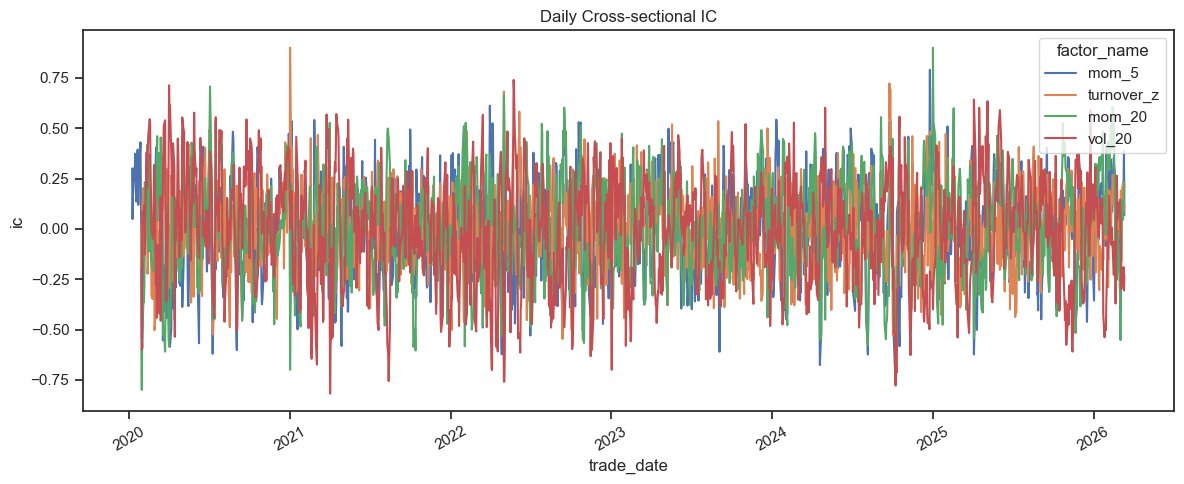

In [9]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=ic_df, x='trade_date', y='ic', hue='factor_name')
plt.title('Daily Cross-sectional IC')
plt.xticks(rotation=30)
plt.tight_layout()

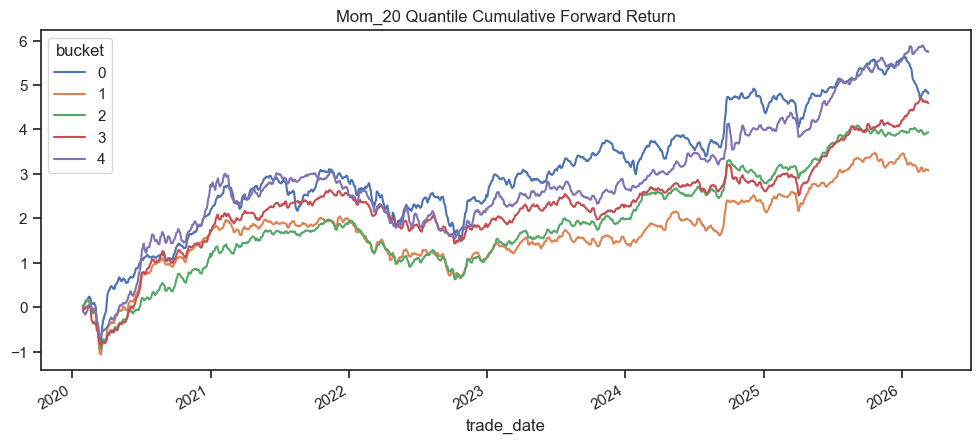

In [10]:
focus = factors[factors['factor_name'] == 'mom_20'].copy()
focus['bucket'] = focus.groupby('trade_date')['factor_value'].transform(lambda s: pd.qcut(s.rank(method='first'), 5, labels=False, duplicates='drop'))
bucket_ret = focus.groupby(['trade_date', 'bucket'])['forward_ret_5d'].mean().reset_index()
bucket_pivot = bucket_ret.pivot(index='trade_date', columns='bucket', values='forward_ret_5d')
bucket_pivot.cumsum().plot(figsize=(12, 5), title='Mom_20 Quantile Cumulative Forward Return')
plt.show()